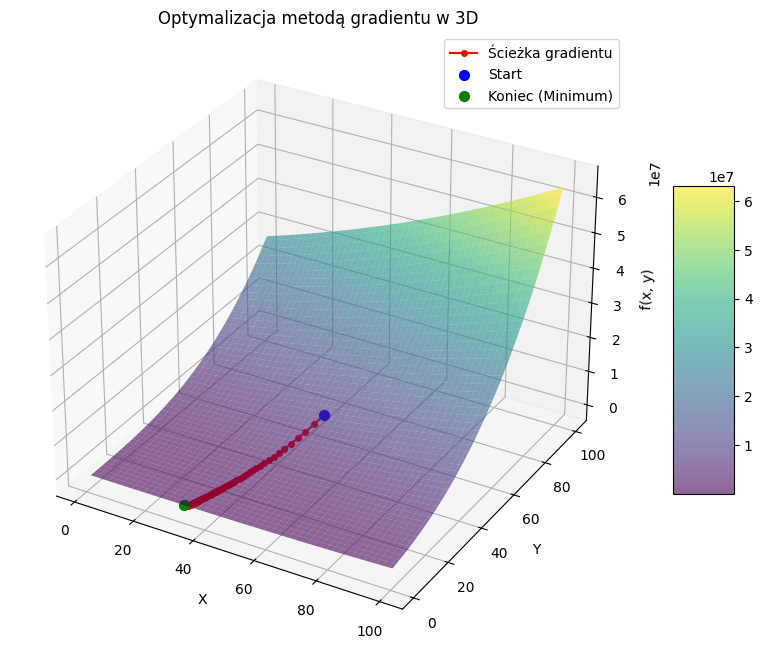

Znalezione minimum w punkcie: X=32.5914, Y=1.0000
Wartość funkcji w tym punkcie: 45020.2513


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def f(x, y):
    return (x + 3*y)**3 - 2*x

def grad_f(x, y):
    df_dx = 3 * (x + 3*y)**2 - 2
    df_dy = 9 * (x + 3*y)**2
    return np.array([df_dx, df_dy])

lr = 0.00001
epochs = 100
start_x, start_y = 50.0, 50.0

history = [[start_x, start_y]]

curr_point = np.array([start_x, start_y])
for _ in range(epochs):
    grad = grad_f(curr_point[0], curr_point[1])
    curr_point = curr_point - lr * grad
    
    curr_point = np.clip(curr_point, 1.0, 100.0)
    history.append(curr_point.copy())

history = np.array(history)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

X = np.linspace(1, 100, 100)
Y = np.linspace(1, 100, 100)
X, Y = np.meshgrid(X, Y)
Z = f(X, Y)

surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6, edgecolor='none')

hist_z = f(history[:, 0], history[:, 1])
ax.plot(history[:, 0], history[:, 1], hist_z, color='red', marker='o', markersize=4, label='Ścieżka gradientu')
ax.scatter(history[0, 0], history[0, 1], hist_z[0], color='blue', s=50, label='Start')
ax.scatter(history[-1, 0], history[-1, 1], hist_z[-1], color='green', s=50, label='Koniec (Minimum)')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('f(x, y)')
ax.set_title('Optymalizacja metodą gradientu w 3D')
ax.legend()
fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()

print(f"Znalezione minimum w punkcie: X={curr_point[0]:.4f}, Y={curr_point[1]:.4f}")
print(f"Wartość funkcji w tym punkcie: {f(curr_point[0], curr_point[1]):.4f}")

In [ ]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1 - np.tanh(x)**2

np.random.seed(42)

W1 = np.random.randn(2, 2)
b1 = np.zeros((1, 2))

W2 = np.random.randn(2, 1)
b2 = np.zeros((1, 1))

X = np.array([[0.5, -0.2]])
y_true = np.array([[0.4]])

Z1 = np.dot(X, W1) + b1
A1 = sigmoid(Z1)

Z2 = np.dot(A1, W2) + b2
A2 = tanh(Z2)

print("=== FORWARD PASS ===")
print("Predykcja sieci (A2):", A2)

dA2 = A2 - y_true

dZ2 = dA2 * tanh_derivative(Z2)
dW2 = np.dot(A1.T, dZ2)
db2 = np.sum(dZ2, axis=0, keepdims=True)

dA1 = np.dot(dZ2, W2.T)

dZ1 = dA1 * sigmoid_derivative(Z1)
dW1 = np.dot(X.T, dZ1)
db1 = np.sum(dZ1, axis=0, keepdims=True)

print("\n=== OBLICZONE GRADIENTY ===")
print("dW2 (Warstwa 2):\n", dW2)
print("db2 (Warstwa 2):\n", db2)
print("dW1 (Warstwa 1):\n", dW1)
print("db1 (Warstwa 1):\n", db1)

=== FORWARD PASS ===
Predykcja sieci (A2): [[-0.21601013]]

=== OBLICZONE GRADIENTY ===
dW2 (Warstwa 2):
 [[-0.31105761]
 [-0.23939233]]
db2 (Warstwa 2):
 [[-0.58726686]]
dW1 (Warstwa 1):
 [[ 0.01712829  0.01660112]
 [-0.00685132 -0.00664045]]
db1 (Warstwa 1):
 [[0.03425658 0.03320224]]
